# Part 2 — Baseline Regression Modeling
**Name:** Areeba Amjad

## Objectives:
- Prepare the engineered dataset for regression modeling.
- Encode categorical variables and split the data into training and testing sets.
- Train and evaluate multiple baseline regression models.
- Compare model performance using MAE, RMSE, R² score, and 5-fold cross-validation.
- Select the best-performing model based on evaluation metrics.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split       # Divides data into training and testing sets.
from sklearn.model_selection import cross_val_score        # Validate model performance using multiple folds.

from sklearn.linear_model import LinearRegression, Ridge   # Basic linear prediction model, model that prevents overfitting
from sklearn.tree import DecisionTreeRegressor             # Tree-based regression model.
from sklearn.ensemble import RandomForestRegressor         # Collection of decision trees for more accurate predictions.

from sklearn.metrics import mean_absolute_error            # Average prediction error
from sklearn.metrics import mean_squared_error             # Average squared prediction error
from sklearn.metrics import r2_score                       # Measures how well the model explains the data

## Loading the Engineered Dataset

In [2]:
ds = pd.read_excel("C:/Users/Laptop Zone/OneDrive/Desktop/Steel_industry_engineered.xlsx")    #Loading the Engineered features dataset
ds["Power_Factor_Ratio"] = ds["Power_Factor_Ratio"].fillna(1)
ds.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour_of_Day,DayofWeek_No,Month,Weekday,Power_Factor_Ratio,High_load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,True,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,True,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,True,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,True,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,True,1.545117,0


## Drop the Unnecessary Columns

In [3]:
ds= ds.drop(columns=["date", "High_load"])
list(ds.columns)

['Usage_kWh',
 'Lagging_Current_Reactive.Power_kVarh',
 'Leading_Current_Reactive_Power_kVarh',
 'CO2(tCO2)',
 'Lagging_Current_Power_Factor',
 'Leading_Current_Power_Factor',
 'NSM',
 'WeekStatus',
 'Day_of_week',
 'Load_Type',
 'Hour_of_Day',
 'DayofWeek_No',
 'Month',
 'Weekday',
 'Power_Factor_Ratio']

## Separate Features and Target

In [4]:
X = ds.drop("Usage_kWh",axis=1)
y = ds["Usage_kWh"]

#### Interpretation:
For regression model building, we need to separate dataset into features (X) and target (y). Target variable is the Usage_kWh that the model has to predict while features are the inputs that are used by the model for prediction. All remaining columns were used as input features. Therefore, Usage_kWh was removed from the feature set (X) and stored separately as the target (y)

## Encoding Categorical columns

In [5]:
category = X.select_dtypes(include="str").columns
print(category)


Index(['WeekStatus', 'Day_of_week', 'Load_Type'], dtype='str')


In [6]:
X = pd.get_dummies(X, columns = category, drop_first=True)

#### Reason:
I used **One-Hot Encoding** to encode the categorical columns because these columns are nominal which means they have no order. One-Hot Encoding creates separate binary columns for each category, preventing the model from assuming an incorrect numerical relationship between categories.

## Train-Test Split

In [7]:
X_train,X_test,y_train,y_test = train_test_split( X, y, test_size=0.2, random_state = 42)

#### Explanation:
The dataset was split into 80% training and 20% test subsets. The training data will be used to train the model while testing data is used to evaluate model's performance on unseen data. Random_state=42 is used to produce same split everytime the code is executed.

## Model Creation

In [8]:
models = { 
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
         }

## Training Model

In [9]:
for name,model in models.items():
    model.fit(X_train,y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Ridge Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


## Evaluating the models

In [10]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

# Creating a summary table
result_st = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R² Score"])
result_st = result_st.round(3)

result_st.style \
    .hide(axis="index") \
    .set_properties(**{"text-align": "left"}) \
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])\
    .highlight_min(subset=["RMSE"], color="lightpink") \
    .highlight_max(subset=["R² Score"], color="lightpink")

Model,MAE,RMSE,R² Score
Linear Regression,5.749000,8.231000,0.940000
Ridge Regression,4.402000,6.362000,0.964000
Decision Tree,0.565000,1.607000,0.998000
Random Forest,0.361000,1.129000,0.999000


### Interpretation:
- The table compares the performance of 4 regression models using MAE, RMSE, R^2 score.
- **Lower MAE and RMSE** values indicates a better prediction accuracy.
- A **higher R^2 score** indicates that model explains the data effectively.
- Random Forest Regression model has lowest RMSE value and higher R^2 score value than rest of the model.

## 5-Fold Cross Validation

In [11]:
cv_results = []
for name,model in models.items():
    scores = cross_val_score( model,X,y,cv=5,scoring="neg_root_mean_squared_error")
    
    mean_rmse = -scores.mean()
    cv_results.append([name,mean_rmse])

cv_table = pd.DataFrame( 
    cv_results,
    columns = ["Model","Mean CV RMSE"]
)
cv_table = cv_table.round(3)

cv_table.style \
    .hide(axis="index") \
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])\
    .set_properties(**{"text-align": "left"}) \
    .highlight_min(subset=["Mean CV RMSE"], color="lightpink")

Model,Mean CV RMSE
Linear Regression,8.536000
Ridge Regression,6.620000
Decision Tree,2.646000
Random Forest,2.142000


### Interpretation:
- 5-Fold Cross Validation trains and tests each model 5 times using different subsets of the dataset.
- Result is the Mean CV RMSE for each model.
- Lower Mean CV RMSE indicates better and more consistent performance.

## Comparison of Test RMSE of all models

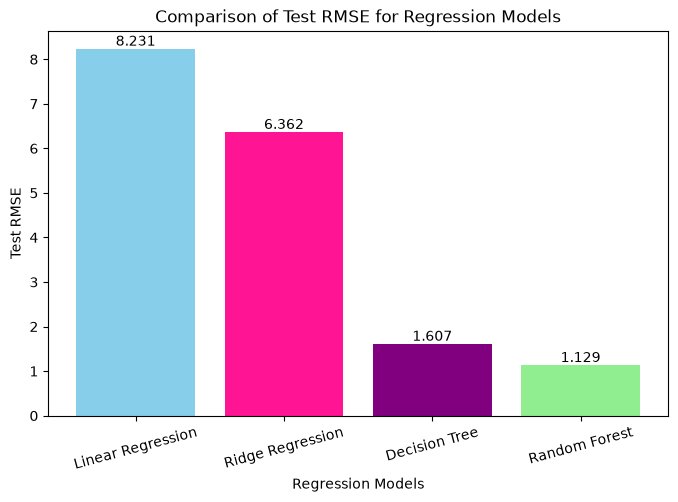

In [12]:
plt.figure(figsize=(8,5))

bars= plt.bar(result_st["Model"], result_st["RMSE"],color=["skyblue","deeppink","purple","lightgreen"])
plt.bar_label(bars)

plt.title("Comparison of Test RMSE for Regression Models")
plt.xlabel("Regression Models")
plt.ylabel("Test RMSE")

plt.xticks(rotation=15)

plt.show()

## Predicted vs Actual Scatter Plot

In [13]:
result_st = result_st.sort_values(by="RMSE")        # Sort the models by RMSE values
best_model = models[result_st.iloc[0]["Model"]]
print(best_model)
y_pred = best_model.predict(X_test)                 # The model uses the features in X_test and predicts the target

RandomForestRegressor(random_state=42)


### Scatter Plot

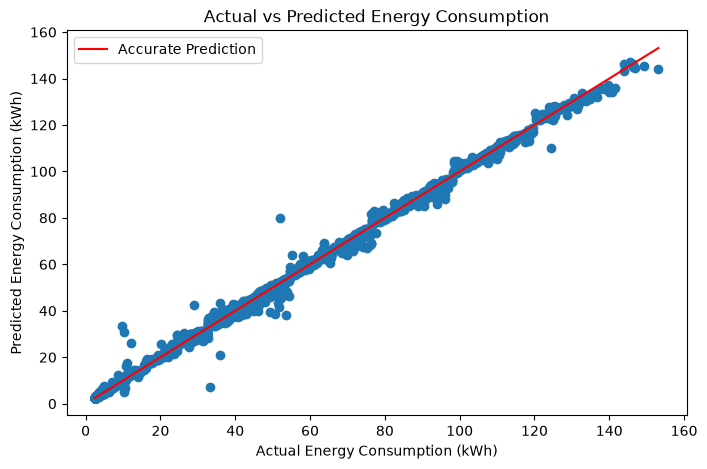

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="-",
    color="red",
    label="Accurate Prediction"
)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")

plt.legend()
plt.show()

### Interpretation:
- Most data points arelies closely with the red **Accurate Prediction** line, indicating that the model predicts energy consumption accurately.
- Only a few points are farther from the line, indiacting there there are some outliers.
- Overall, the model has a good predictive performance. 

##  Model Selection

- According to my analysis, **Random Forest Regression** model had the best performance overall with an accurate and reliable prediction of energy consumption. 
- It had the **lowest RMSE value** i.e 1.129 and **highest R^2 score** i.e 0.999 as compared to other models. 
- After performing 5-Fold Cross Validation, this model had the **lowest avergae RMSE** i.e 2.142 indicating consistent performance across the five folds. 
- The Test RMSE and Mean CV RMSE is very close hence **no significant signs of overfitting**.
- Therefore, Random Forest Regression model is selected as the final model for future energy consumption prediction.